Import required libraries and set up the environment.



In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


Task 1 — Load and Inspect the Dataset
Load both CSV files, convert to NumPy arrays, and display dataset statistics.

In [ ]:
"""
TASK 1: Load and Inspect the Dataset
"""
# Load ground truth objects
ground_truth_df = pd.read_csv('ground_truth_boxes.csv')
predicted_df = pd.read_csv('predicted_boxes.csv')

# Convert bounding boxes into to NumPy arrays
gt_boxes = ground_truth_df[['x1', 'y1', 'x2', 'y2']].values
pred_boxes = predicted_df[['x1', 'y1', 'x2', 'y2']].values
pred_scores = predicted_df['confidence'].values
pred_ids = predicted_df['prediction_id'].values
gt_ids = ground_truth_df['object_id'].values


print(f"Number of Ground Truth objects: {len(gt_boxes)}")
print(f"Number of Predicted boxes: {len(pred_boxes)}")

Number of Ground Truth objects: 8
Number of Predicted boxes: 12


Task 2 — Implement Intersection over Union (IoU)

Compute IoU between two boxes, then compute IoU matrix between all predictions and ground truths.

In [ ]:
"""
TASK 2: Implement Intersection over Union (IoU)
"""
def compute_iou(boxA, boxB):
    """
    Compute Intersection over Union (IoU) between two bounding boxes.

    Parameters:
        boxA: [x1, y1, x2, y2] - top-left and bottom-right coordinates
        boxB: [x1, y1, x2, y2] - top-left and bottom-right coordinates

    Returns:
        iou: float between 0 and 1
    """
    # Extract coordinates
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # Compute intersection area
    inter_width = max(0, xB - xA)
    inter_height = max(0, yB - yA)
    inter_area = inter_width * inter_height

    # Compute areas of each box
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # Compute union area
    union_area = areaA + areaB - inter_area

    # Avoid division by zero
    if union_area == 0:
        return 0.0

    iou = inter_area / union_area
    return iou

# Compute IoU matrix between all predictions and all ground truths
def compute_iou_matrix(pred_boxes, gt_boxes):
    """
    Compute IoU between every prediction and every ground truth box.

    Returns:
        iou_matrix: (num_predictions, num_ground_truth) array of IoU values
    """
    num_preds = len(pred_boxes)
    num_gts = len(gt_boxes)
    iou_matrix = np.zeros((num_preds, num_gts))

    for i, pred_box in enumerate(pred_boxes):
        for j, gt_box in enumerate(gt_boxes):
            iou_matrix[i, j] = compute_iou(pred_box, gt_box)

    return iou_matrix

# Compute the IoU matrix
iou_matrix = compute_iou_matrix(pred_boxes, gt_boxes)

print(f"IoU matrix shape: {iou_matrix.shape}")
print(f"Maximum IoU found: {iou_matrix.max():.4f}")
print(f"Minimum IoU found: {iou_matrix.min():.4f}")
print(f"Mean IoU: {iou_matrix.mean():.4f}")
print("Sample IoU matrix (first 5 predictions vs first 5 GT):")
print(iou_matrix[:5, :5])

IoU matrix shape: (12, 8)
Maximum IoU found: 0.7052
Minimum IoU found: 0.0000
Mean IoU: 0.0910
Sample IoU matrix (first 5 predictions vs first 5 GT):
[[0.70522734 0.32217834 0.21733881 0.10605656 0.15257215]
 [0.45962264 0.45887152 0.39050536 0.25375626 0.109375  ]
 [0.08834037 0.235      0.30923147 0.12129528 0.        ]
 [0.01527939 0.22880025 0.07966805 0.61560119 0.        ]
 [0.1440613  0.         0.         0.         0.38638858]]


Task 3 — Apply Non-Maximum Suppression (NMS)

Implement NMS to remove duplicate detections with IoU > threshold.

In [ ]:
"""
TASK 3: Apply Non-Maximum Suppression (NMS)
"""
def non_max_suppression(boxes, scores, iou_threshold=0.5):
    """
    Apply Non-Maximum Suppression to remove redundant detections.

    Parameters:
        boxes: (N, 4) array of bounding boxes
        scores: (N,) array of confidence scores
        iou_threshold: IoU threshold for suppression

    Returns:
        keep_indices: list of indices to keep
    """
    if len(boxes) == 0:
        return []

    # Convert to numpy arrays
    boxes = np.array(boxes)
    scores = np.array(scores)

    # Sort boxes by confidence (descending)
    sorted_indices = np.argsort(scores)[::-1]

    keep_indices = []

    while len(sorted_indices) > 0:
        # Pick the highest scoring box
        current_idx = sorted_indices[0]
        keep_indices.append(current_idx)

        if len(sorted_indices) == 1:
            break

        # Compute IoU between current box and all remaining boxes
        remaining_indices = sorted_indices[1:]
        remaining_boxes = boxes[remaining_indices]
        current_box = boxes[current_idx]

        # Compute IoUs
        ious = []
        for i, box in enumerate(remaining_boxes):
            iou = compute_iou(current_box, box)
            ious.append(iou)

        # Keep boxes with IoU <= threshold (remove those with high overlap)
        keep_condition = np.array(ious) <= iou_threshold
        sorted_indices = remaining_indices[keep_condition]

    return keep_indices

# Apply NMS
iou_threshold_nms = 0.5
keep_indices = non_max_suppression(pred_boxes, pred_scores, iou_threshold_nms)

# Get filtered predictions
nms_boxes = pred_boxes[keep_indices]
nms_scores = pred_scores[keep_indices]
nms_ids = pred_ids[keep_indices]


print(f"IOU threshold for NMS: {iou_threshold_nms}")
print(f"Number of detections before NMS: {len(pred_boxes)}")
print(f"Number of detections after NMS: {len(nms_boxes)}")
print(f"Reduction: {len(pred_boxes) - len(nms_boxes)} boxes removed ({100*(1 - len(nms_boxes)/len(pred_boxes)):.1f}%)")

IOU threshold for NMS: 0.5
Number of detections before NMS: 12
Number of detections after NMS: 10
Reduction: 2 boxes removed (16.7%)


Task 4 — Match Predictions to Ground Truth

For each predicted box, assign it to a ground truth box if IoU ≥ 0.5 with one-to-one matching.

In [ ]:
"""
TASK 4: Match Predictions to Ground Truth
"""
def match_predictions_to_ground_truth(pred_boxes, gt_boxes, iou_threshold=0.5):
    """
    Match predictions to ground truth boxes using IoU threshold.
    Each GT box can be matched at most once.

    Returns:
        matches: dict mapping prediction index -> ground truth index
        unmatched_preds: list of prediction indices with no match
        unmatched_gts: list of ground truth indices with no match
    """
    num_preds = len(pred_boxes)
    num_gts = len(gt_boxes)

    # Compute IoU matrix
    iou_matrix = compute_iou_matrix(pred_boxes, gt_boxes)

    # Track matches
    matches = {}  # pred_idx -> gt_idx
    matched_gts = set()
    matched_preds = set()

    # Sort predictions by confidence (highest first) for greedy matching
    # We'll use the provided scores (assuming they're already available)
    sorted_pred_indices = np.argsort(pred_scores if len(pred_scores) == num_preds else
                                     np.ones(num_preds))[::-1]

    for pred_idx in sorted_pred_indices:
        # Find best matching GT for this prediction
        best_gt_idx = -1
        best_iou = 0.0

        for gt_idx in range(num_gts):
            if gt_idx in matched_gts:
                continue
            iou = iou_matrix[pred_idx, gt_idx]
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        # If best IoU >= threshold, match them
        if best_iou >= iou_threshold and best_gt_idx != -1:
            matches[pred_idx] = best_gt_idx
            matched_gts.add(best_gt_idx)
            matched_preds.add(pred_idx)

    # Find unmatched predictions and ground truths
    unmatched_preds = [i for i in range(num_preds) if i not in matched_preds]
    unmatched_gts = [i for i in range(num_gts) if i not in matched_gts]

    return matches, unmatched_preds, unmatched_gts

# Match predictions to ground truth
iou_threshold_match = 0.5
matches, unmatched_preds, unmatched_gts = match_predictions_to_ground_truth(
    nms_boxes, gt_boxes, iou_threshold_match
)

# Determine TP, FP, FN
true_positives = len(matches)
false_positives = len(unmatched_preds)
false_negatives = len(unmatched_gts)

print(f"IoU threshold for matching: {iou_threshold_match}")
print(f"Matches found: {true_positives}")
print(f"Unmatched predictions (FP): {false_positives}")
print(f"Unmatched ground truths (FN): {false_negatives}")
print(f"True Positives (TP): {true_positives}")
print(f"False Positives (FP): {false_positives}")
print(f"False Negatives (FN): {false_negatives}")

IoU threshold for matching: 0.5
Matches found: 3
Unmatched predictions (FP): 7
Unmatched ground truths (FN): 5
True Positives (TP): 3
False Positives (FP): 7
False Negatives (FN): 5


Task 5 — Compute Precision and Recall
Calculate precision and recall from TP, FP, FN counts.

In [ ]:
"""
TASK 5: Compute Precision and Recall
"""
def compute_precision_recall(tp, fp, fn):
    """
    Compute precision and recall from TP, FP, FN counts.
    """
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall

precision, recall = compute_precision_recall(true_positives, false_positives, false_negatives)

print(f"Precision = {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall = {recall:.4f} ({recall*100:.2f}%)")

Precision = 0.3000 (30.00%)
Recall = 0.3750 (37.50%)


Task 6 — Compute Average Precision (AP)

Sort detections by confidence, compute PR curve at multiple thresholds, and calculate AP using trapezoidal integration.

IoU threshold for AP: 0.5
Average Precision (AP@0.5) = 0.4792 (47.92%)


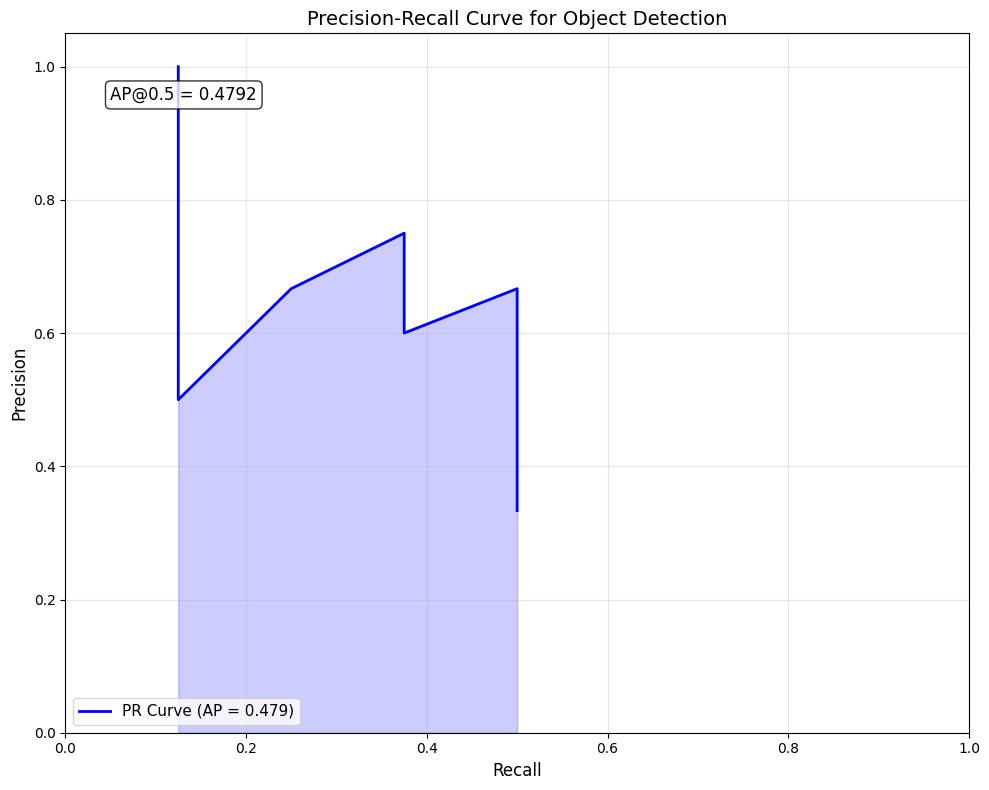

In [ ]:
"""
TASK 6: Compute Average Precision (AP)
"""
def compute_precision_recall_curve(pred_boxes, pred_scores, gt_boxes, iou_threshold=0.5):
    """
    Compute precision-recall curve by varying confidence threshold.
    Returns: precisions, recalls, thresholds
    """
    # Sort predictions by confidence (descending)
    sorted_indices = np.argsort(pred_scores)[::-1]
    sorted_boxes = pred_boxes[sorted_indices]
    sorted_scores = pred_scores[sorted_indices]

    num_preds = len(sorted_boxes)
    num_gts = len(gt_boxes)

    # Track which GT boxes have been matched
    gt_matched = np.zeros(num_gts, dtype=bool)

    precisions = []
    recalls = []
    thresholds = []

    tp_cumulative = 0
    fp_cumulative = 0

    for i in range(num_preds):
        # Check if this prediction matches any GT
        pred_box = sorted_boxes[i]
        best_iou = 0.0
        best_gt_idx = -1

        for j in range(num_gts):
            if gt_matched[j]:
                continue
            iou = compute_iou(pred_box, gt_boxes[j])
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j

        # Determine if this is TP or FP
        if best_iou >= iou_threshold and best_gt_idx != -1:
            # This is a TP
            tp_cumulative += 1
            gt_matched[best_gt_idx] = True
        else:
            # This is a FP
            fp_cumulative += 1

        # Compute precision and recall at this threshold
        precision = tp_cumulative / (tp_cumulative + fp_cumulative) if (tp_cumulative + fp_cumulative) > 0 else 0.0
        recall = tp_cumulative / num_gts if num_gts > 0 else 0.0

        precisions.append(precision)
        recalls.append(recall)
        thresholds.append(sorted_scores[i])

    return np.array(precisions), np.array(recalls), np.array(thresholds)

def compute_average_precision(precisions, recalls):
    """
    Compute Average Precision using trapezoidal integration.
    """
    if len(precisions) == 0 or len(recalls) == 0:
        return 0.0

    # Add endpoints for integration
    precisions = np.array(precisions)
    recalls = np.array(recalls)

    # Sort by recall
    sorted_indices = np.argsort(recalls)
    recalls = recalls[sorted_indices]
    precisions = precisions[sorted_indices]

    # Add (0, 1) and (1, 0) endpoints if needed
    if recalls[0] != 0:
        recalls = np.insert(recalls, 0, 0)
        precisions = np.insert(precisions, 0, precisions[0])

    if recalls[-1] != 1:
        recalls = np.append(recalls, 1)
        precisions = np.append(precisions, 0)

    # Ensure precision doesn't increase (monotonic decreasing)
    for i in range(len(precisions) - 1, 0, -1):
        if precisions[i-1] < precisions[i]:
            precisions[i-1] = precisions[i]

    # Compute AP using trapezoidal integration
    ap = np.trapz(precisions, recalls)
    return ap

# Compute precision-recall curve
iou_threshold_ap = 0.5
precisions, recalls, thresholds = compute_precision_recall_curve(
    pred_boxes, pred_scores, gt_boxes, iou_threshold_ap
)

# Compute Average Precision
ap = compute_average_precision(precisions, recalls)


print(f"IoU threshold for AP: {iou_threshold_ap}")
print(f"Average Precision (AP@0.5) = {ap:.4f} ({ap*100:.2f}%)")


# Plot Precision-Recall Curve
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(recalls, precisions, 'b-', linewidth=2, label=f'PR Curve (AP = {ap:.3f})')
ax.fill_between(recalls, 0, precisions, alpha=0.2, color='blue')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve for Object Detection', fontsize=14)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=11)
ax.text(0.05, 0.95, f'AP@0.5 = {ap:.4f}', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150)
plt.show()